MSCS 634 — Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

Name: Ujjwal Khadka  
Course title: MSCS 634  
Lab Assignment title: Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering
Due Date: March 15, 2026

Dataset Source: sklearn.datasets
File Used: Wine Dataset

## 1) Imports + Load Dataset

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

from scipy.cluster.hierarchy import dendrogram, linkage


In [3]:
# Loading the Wine dataset from sklearn datasets
wine = load_wine()

X = wine.data
y = wine.target
feature_names = wine.feature_names

# Putting the data into a DataFrame
df = pd.DataFrame(X, columns=feature_names)

print(df.head())
print(df.info())
print(df.describe())


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [4]:
# Standardizing the dataset 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset standardized")


Dataset standardized


## 2) Hierarchical Clustering

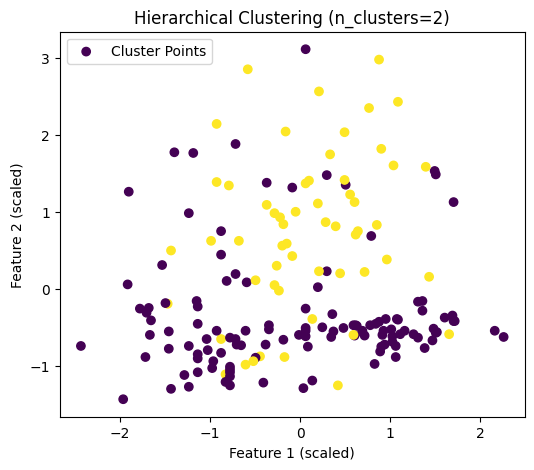

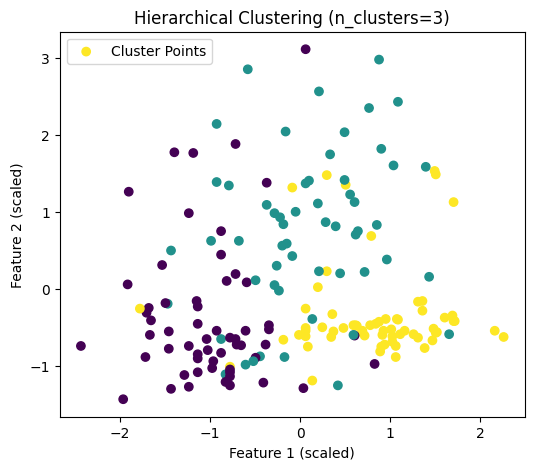

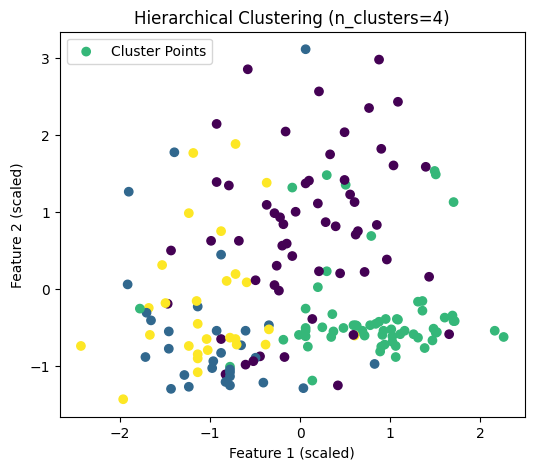

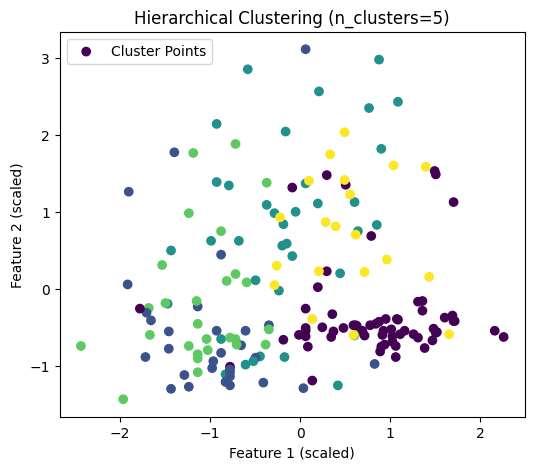

In [5]:
# Applying agglomerative hierarchical clustering with different cluster values
cluster_values = [2,3,4,5]

for k in cluster_values:

    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)
    
    # Plotting the scatter plots
    plt.figure(figsize=(6,5))
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", label="Cluster Points")

    plt.title(f"Hierarchical Clustering (n_clusters={k})")
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    plt.legend()

    plt.show()


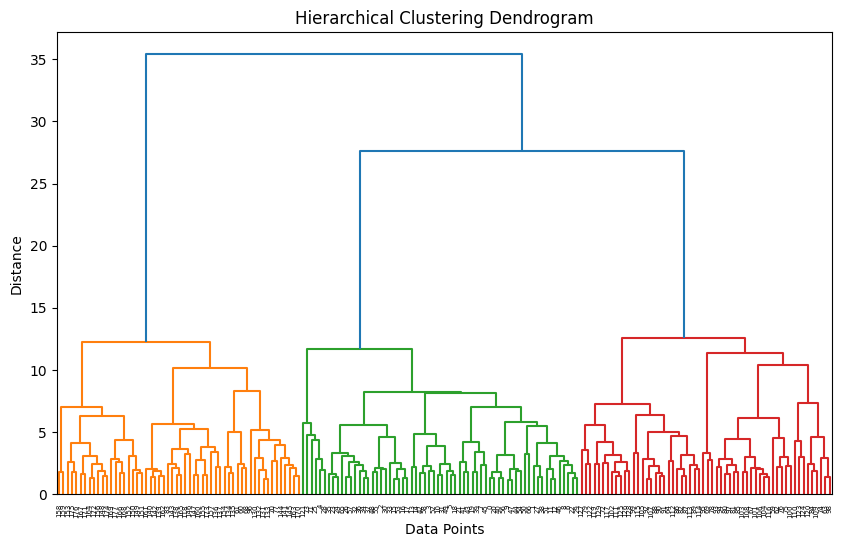

In [6]:
# Plotting the dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()


## 3) DBSCAN Clustering

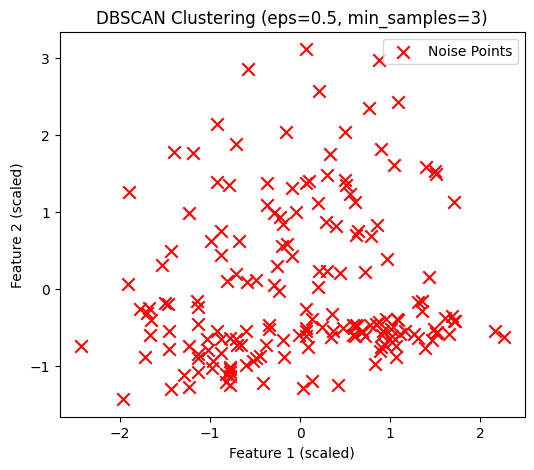

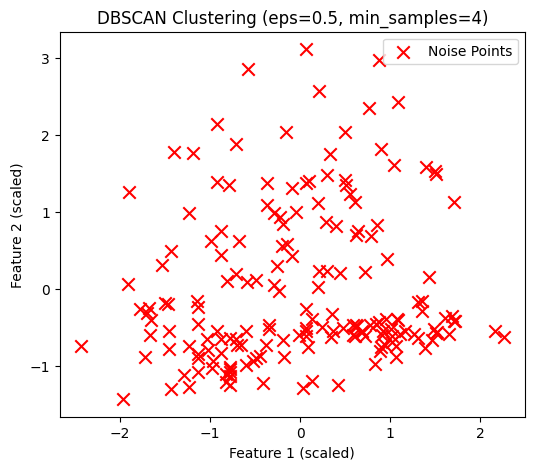

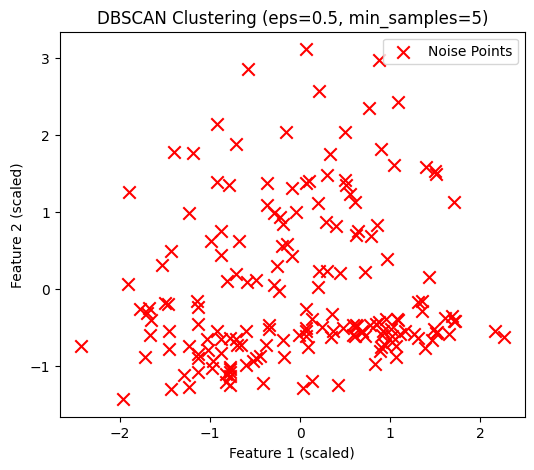

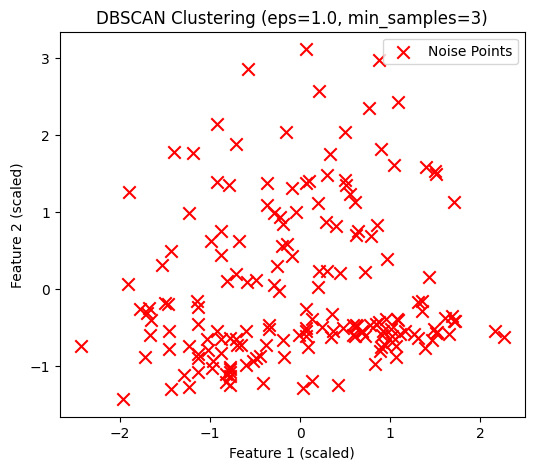

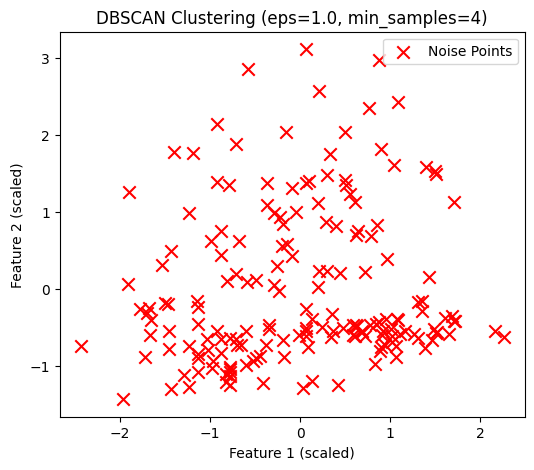

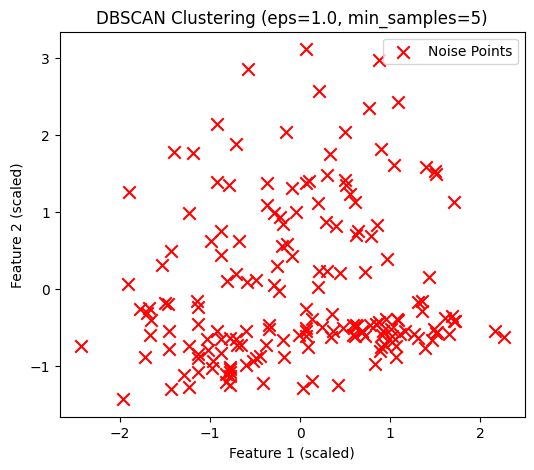

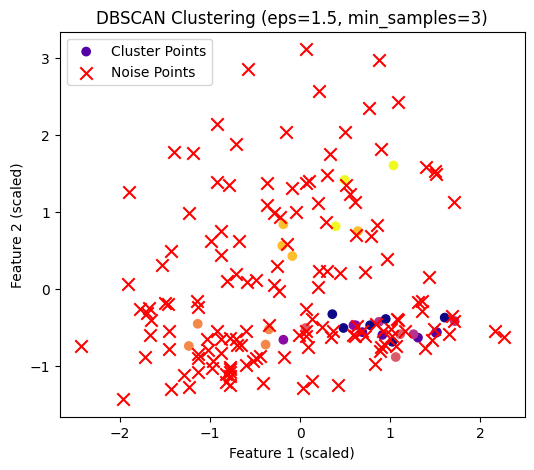

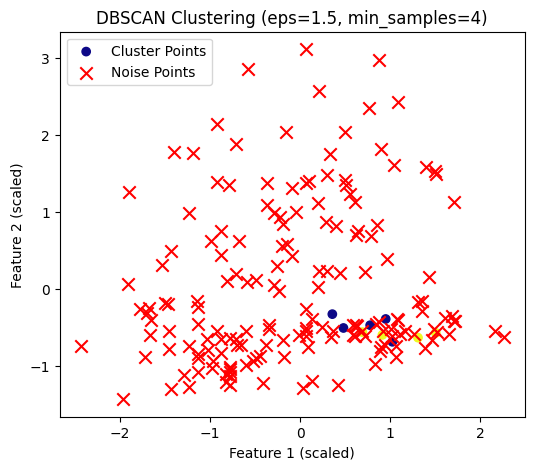

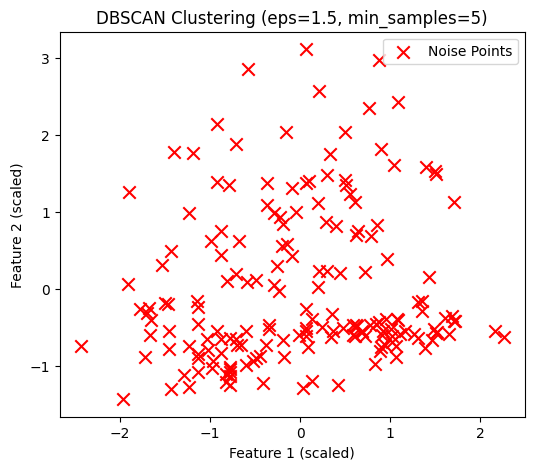

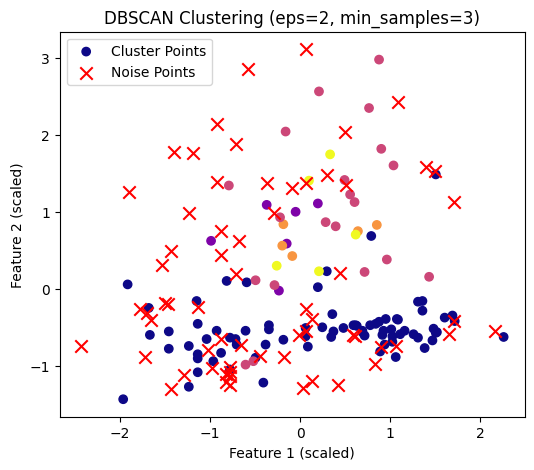

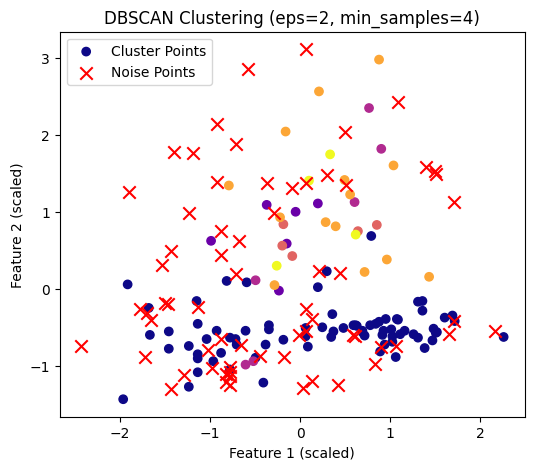

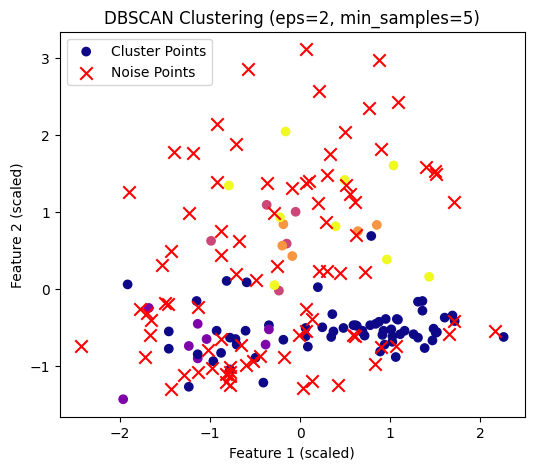

    eps  min_samples  n_clusters  n_noise  silhouette_score  \
0   0.5            3           0      178               NaN   
1   0.5            4           0      178               NaN   
2   0.5            5           0      178               NaN   
3   1.0            3           0      178               NaN   
4   1.0            4           0      178               NaN   
5   1.0            5           0      178               NaN   
6   1.5            3           8      147         -0.276769   
7   1.5            4           2      169         -0.072377   
8   1.5            5           0      178               NaN   
9   2.0            3           5       64          0.031407   
10  2.0            4           6       66          0.028567   
11  2.0            5           5       85         -0.032906   

    homogeneity_score  completeness_score  
0            0.000000            1.000000  
1            0.000000            1.000000  
2            0.000000            1.000000  
3   

In [7]:
# Using DBSCAN algorithm with various eps and min samples values

eps_values = [0.5, 1.0, 1.5, 2]
min_samples_values = [3, 4, 5]

dbscan_results = []

for eps in eps_values:
    for min_s in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        cluster_mask = labels != -1
        noise_mask = labels == -1

        plt.figure(figsize=(6,5))

        # Plotting cluster points
        if np.any(cluster_mask):
            plt.scatter(
                X_scaled[cluster_mask, 0],
                X_scaled[cluster_mask, 1],
                c=labels[cluster_mask],
                cmap="plasma",
                label="Cluster Points"
            )

        # Plotting noise points
        if np.any(noise_mask):
            plt.scatter(
                X_scaled[noise_mask, 0],
                X_scaled[noise_mask, 1],
                color="red",
                marker="x",
                s=80,
                label="Noise Points"
            )

        plt.title(f"DBSCAN Clustering (eps={eps}, min_samples={min_s})")
        plt.xlabel("Feature 1 (scaled)")
        plt.ylabel("Feature 2 (scaled)")
        plt.legend()
        plt.show()

        # Metrics for report
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = None

        homo = homogeneity_score(y, labels)
        comp = completeness_score(y, labels)

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_s,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": sil,
            "homogeneity_score": homo,
            "completeness_score": comp
        })

#Printing the results
results_df = pd.DataFrame(dbscan_results)
print(results_df)

## 4) Analysis and Insights


### Compare the results between Hierarchical and DBSCAN Clustering. 

- Hierarchical Clustering groups wine sample data based upon the distance between individual data points.

- A dendrogram is a tree diagram that allows you to see how clusters merge as they form from individual samples.

- DBSCAN Clustering groups data points based upon the density of the points rather than the hierarchical distance relationship of the data points.

- DBSCAN identifies noise samples that do not fit into any cluster.

- Each sample is assigned to a cluster when using Hierarchical Clustering, whereas DBSCAN can assign some samples as noise samples if they don't meet its criteria.

### Discuss how the choice of parameters influenced the clustering outcomes.

- n_clusters parameter is used to select the number of clusters in Hierarchical Clustering.

- If n_clusters has a small value it will produce fewer but larger clusters, if n_clusters has a large value it will produce more clusters with less detail.

- With DBSCAN, there are two major parameters which are eps and min_samples. When using a smaller eps value, more samples will be classified as "noise", while larger eps values will group more samples into clusters. Changing the value of min_samples can affect whether clusters can be easily formed, or if the database is too sparse to create them.

## Reflect on the strengths and weaknesses of each algorithm based on your results. 

### Advantages of Hierarchical Clustering:

- It's easy to view the relationships between clusters by creating a dendrogram.

- It does not require specifying the cluster centers.

### Disadvantages of Hierarchical Clustering:

- The number of clusters is needed to be decided before begining the analysis.

- It doesn't recognize noise samples.

### Advantages of DBSCAN:

- It recognizes clusters and can identify noise samples without manual input.

- It works well for finding clusters that are based on density.

### Disadvantages of DBSCAN:

- It requires careful selection of the parameters used to define what constitutes a cluster.

- If the density of dataset varies significantly, the performance may decrease.